# Tweet Sentiment Classification using RNN, LSTM and Word2Vec Embeddings

**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Task:** Part III - Natural Language Processing  
**Dataset:** IMDb Movie Reviews (Binary Sentiment Classification)  


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 0 - Setup and Installation

In [2]:
!pip install gensim --quiet
!pip install contractions --quiet
!pip install wordcloud --quiet
!python -c "import nltk; nltk.download('stopwords', quiet=True); nltk.download('wordnet', quiet=True); nltk.download('omw-1.4', quiet=True)"
print("installation complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.7 MB/s eta 0:00:00
installation complete


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud
from collections import Counter

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : True


## Section 1 - Load Dataset

In [4]:
import zipfile, os

archive_path   = '/content/drive/MyDrive/AI & Machine Learning/Assignment/Task 2 (Text Classification)/5. Movie Review Dataset-20260508T183008Z-3-001.zip'
output_folder  = '/content/drive/MyDrive/AI & Machine Learning/Assignment/Task 2 (Text Classification)/review_data'
os.makedirs(output_folder, exist_ok=True)

with zipfile.ZipFile(archive_path, 'r') as zf:
    zf.extractall(output_folder)

print(f'extracted to: {output_folder}')
print(os.listdir(output_folder))

extracted to: /content/drive/MyDrive/AI & Machine Learning/Assignment/Task 2 (Text Classification)/review_data
['5. Movie Review Dataset']


In [7]:
df_train = pd.read_csv('/content/drive/MyDrive/AI & Machine Learning/Assignment/Task 2 (Text Classification)/review_data/5. Movie Review Dataset/train_movie_review.csv')
df_val   = pd.read_csv('/content/drive/MyDrive/AI & Machine Learning/Assignment/Task 2 (Text Classification)/review_data/5. Movie Review Dataset/val_movie_review.csv')
df_test  = pd.read_csv('/content/drive/MyDrive/AI & Machine Learning/Assignment/Task 2 (Text Classification)/review_data/5. Movie Review Dataset/test_movie_review.csv')

for df in [df_train, df_val, df_test]:
    df.columns = [c.strip().lower() for c in df.columns]

df_train.dropna(subset=['sentiment'], inplace=True)
df_val.dropna(subset=['sentiment'],   inplace=True)
df_test.dropna(subset=['sentiment'],  inplace=True)

for df in [df_train, df_val, df_test]:
    df['sentiment'] = df['sentiment'].astype(int)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {df_train.shape}")
print(f"Val   : {df_val.shape}")
print(f"Test  : {df_test.shape}")
df_train.head(3)

Train : (35000, 3)
Val   : (5000, 3)
Test  : (10000, 3)


,unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0


## Section 2 - Data Understanding, Analysis and Visualization

### 2.1 Dataset Overview

In [8]:
record_count = len(df_train) + len(df_val) + len(df_test)
print(f"Total reviews  : {record_count}")
print("Objective      : Binary sentiment classification (positive / negative)")
print()

for df, split_name in [(df_train, 'Train'), (df_val, 'Val'), (df_test, 'Test')]:
    vc = df['sentiment'].value_counts()
    print(f"{split_name:6s}  Negative={vc.get(0, 0)}  Positive={vc.get(1, 0)}  Total={len(df)}")

Total reviews  : 50000
Objective      : Binary sentiment classification (positive / negative)

Train   Negative=17584  Positive=17416  Total=35000
Val     Negative=2455  Positive=2545  Total=5000
Test    Negative=4961  Positive=5039  Total=10000


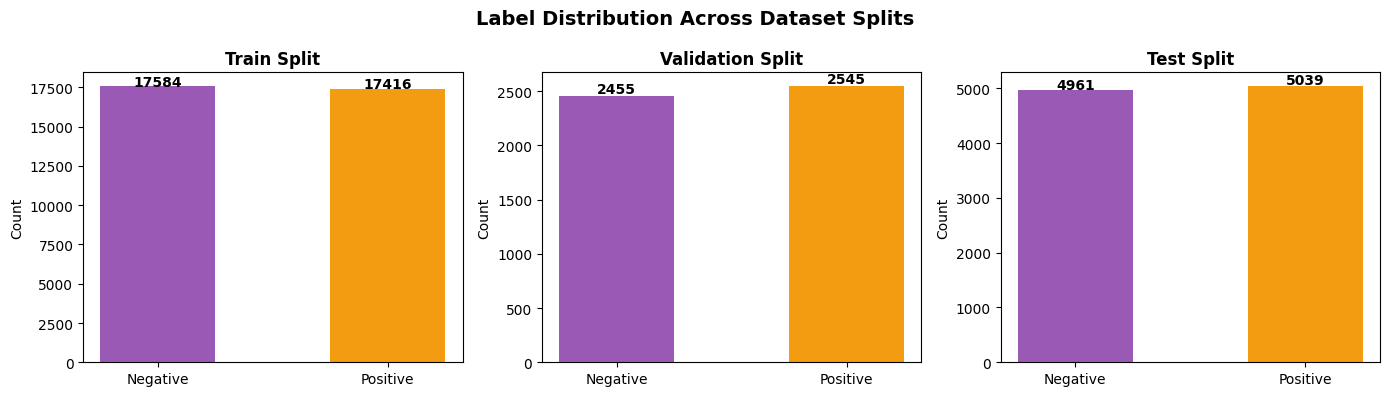

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bar_palette = ['#9b59b6', '#f39c12']

for ax, (df, split_title) in zip(axes, [(df_train, 'Train Split'),
                                         (df_val,   'Validation Split'),
                                         (df_test,  'Test Split')]):
    class_counts = df['sentiment'].value_counts().sort_index()
    bar_objs = ax.bar(['Negative', 'Positive'], class_counts.values, color=bar_palette, width=0.5)
    ax.set_title(split_title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for b, v in zip(bar_objs, class_counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('Label Distribution Across Dataset Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

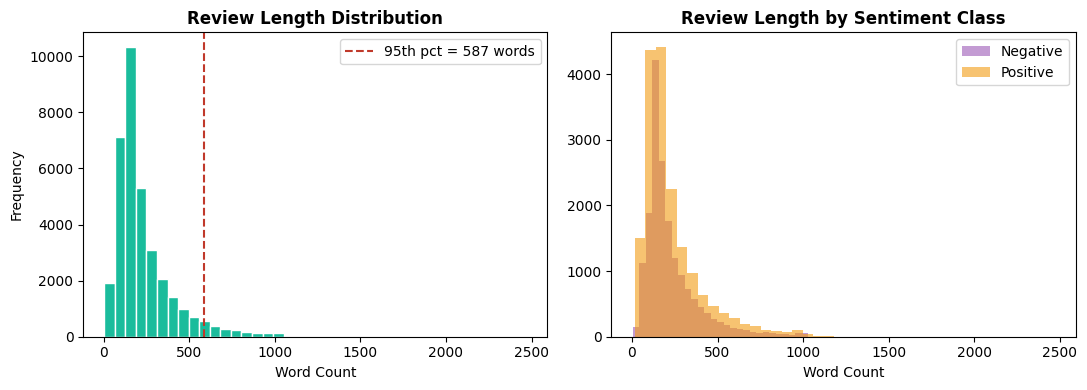

Mean   : 230.7 words
Median : 173.0 words
95th percentile: 587 words


In [11]:
df_train['token_count'] = df_train['review'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_train['token_count'], bins=40, color='#1abc9c', edgecolor='white')
pct_95 = int(df_train['token_count'].quantile(0.95))
axes[0].axvline(pct_95, color='#c0392b', linestyle='--', label=f'95th pct = {pct_95} words')
axes[0].set_title('Review Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

for sentiment_val, lbl, clr in [(0, 'Negative', '#9b59b6'), (1, 'Positive', '#f39c12')]:
    axes[1].hist(df_train[df_train['sentiment'] == sentiment_val]['token_count'],
                 bins=40, alpha=0.6, label=lbl, color=clr)
axes[1].set_title('Review Length by Sentiment Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean   : {df_train['token_count'].mean():.1f} words")
print(f"Median : {df_train['token_count'].median():.1f} words")
print(f"95th percentile: {pct_95} words")

## Section 3 - Text Preprocessing, Tokenization and Sequence Padding

### 3.1 Text Cleaning Pipeline

In [12]:
STOP_SET = set(stopwords.words('english'))

NEGATION_WORDS = {'not', 'no', 'nor', 'neither', 'never', 'none', "n't"}
STOP_SET = STOP_SET - NEGATION_WORDS

word_lemmatizer = WordNetLemmatizer()

CONTRACTION_DICT = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am"
}

def expand_short_forms(text):
    for k, v in CONTRACTION_DICT.items():
        text = text.replace(k, v)
    return text

def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = expand_short_forms(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    word_tokens = text.split()
    word_tokens = [word_lemmatizer.lemmatize(w) for w in word_tokens if w not in STOP_SET]
    return ' '.join(word_tokens)

print("Applying preprocessing pipeline...")
start_ts = time.time()
df_train['cleaned'] = df_train['review'].astype(str).apply(preprocess_text)
df_val['cleaned']   = df_val['review'].astype(str).apply(preprocess_text)
df_test['cleaned']  = df_test['review'].astype(str).apply(preprocess_text)
print(f"Completed in {time.time() - start_ts:.1f}s")

print("\nOriginal:")
print(df_train['review'].iloc[0][:300])
print("\nProcessed:")
print(df_train['cleaned'].iloc[0][:300])

Applying preprocessing pipeline...
Completed in 35.7s

Original:
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terribl

Processed:
avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained amamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another no characterisation dance number heavily choreographed


### 3.2 Word Clouds and Frequency Analysis

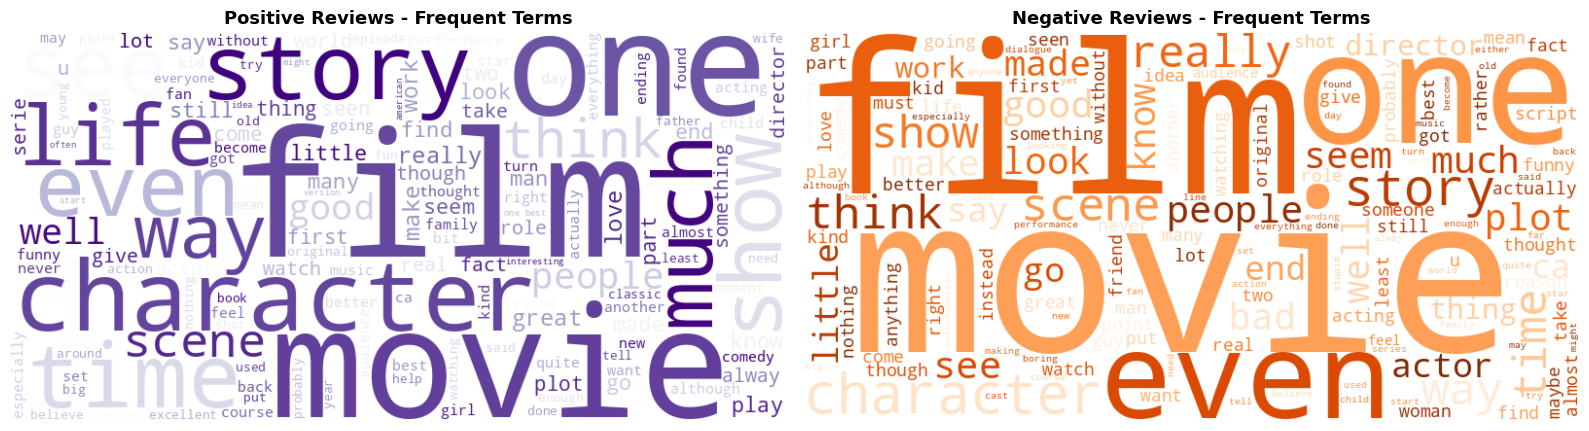

In [13]:
positive_corpus = ' '.join(df_train[df_train['sentiment'] == 1]['cleaned'])
negative_corpus = ' '.join(df_train[df_train['sentiment'] == 0]['cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Purples', max_words=150).generate(positive_corpus)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Frequent Terms', fontsize=13, fontweight='bold')
axes[0].axis('off')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Oranges', max_words=150).generate(negative_corpus)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Frequent Terms', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

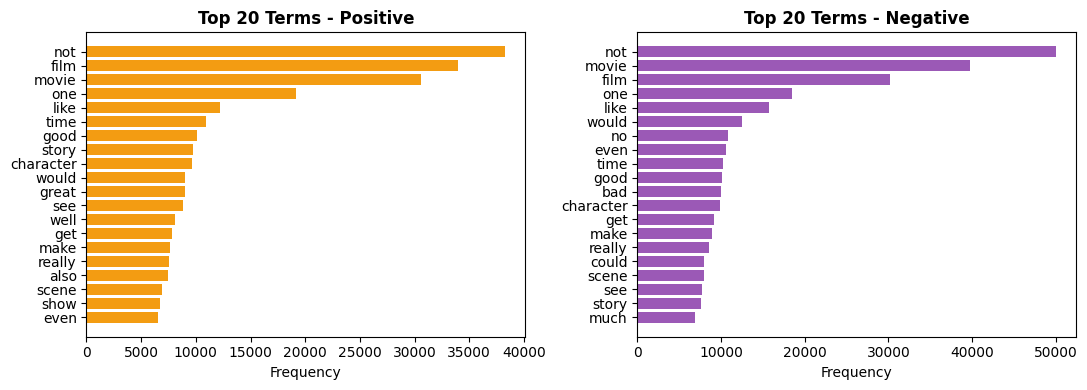

In [15]:
def fetch_top_words(corpus, n=20):
    words, counts = zip(*Counter(corpus.split()).most_common(n))
    return list(words), list(counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, corpus, chart_title, bar_color in [
        (axes[0], positive_corpus, 'Top 20 Terms - Positive', '#f39c12'),
        (axes[1], negative_corpus, 'Top 20 Terms - Negative', '#9b59b6')]:
    w_list, c_list = fetch_top_words(corpus)
    ax.barh(w_list[::-1], c_list[::-1], color=bar_color)
    ax.set_title(chart_title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Tokenization and Sequence Padding

In [16]:
DICTIONARY_SIZE  = 10000
UNKNOWN_TOKEN    = '<OOV>'
SEQ_LEN_RNN      = 100
SEQ_LEN_LSTM     = 150
SEQ_LEN_GLOVE    = 150

text_tokenizer = Tokenizer(num_words=DICTIONARY_SIZE, oov_token=UNKNOWN_TOKEN)
text_tokenizer.fit_on_texts(df_train['cleaned'])
vocab_index = text_tokenizer.word_index
print(f"Full vocabulary size : {len(vocab_index)}")
print(f"Retained top        : {DICTIONARY_SIZE} words")

def encode_sequences(texts, maxlen):
    int_seqs = text_tokenizer.texts_to_sequences(texts)
    return pad_sequences(int_seqs, maxlen=maxlen, padding='post', truncating='post')

tr_rnn  = encode_sequences(df_train['cleaned'], SEQ_LEN_RNN)
vl_rnn  = encode_sequences(df_val['cleaned'],   SEQ_LEN_RNN)
te_rnn  = encode_sequences(df_test['cleaned'],  SEQ_LEN_RNN)

tr_lstm = encode_sequences(df_train['cleaned'], SEQ_LEN_LSTM)
vl_lstm = encode_sequences(df_val['cleaned'],   SEQ_LEN_LSTM)
te_lstm = encode_sequences(df_test['cleaned'],  SEQ_LEN_LSTM)

tr_glv  = encode_sequences(df_train['cleaned'], SEQ_LEN_GLOVE)
vl_glv  = encode_sequences(df_val['cleaned'],   SEQ_LEN_GLOVE)
te_glv  = encode_sequences(df_test['cleaned'],  SEQ_LEN_GLOVE)

lbl_train = df_train['sentiment'].values
lbl_val   = df_val['sentiment'].values
lbl_test  = df_test['sentiment'].values

print(f"\nModel 1 (RNN)   train shape : {tr_rnn.shape}")
print(f"Model 2 (LSTM)  train shape : {tr_lstm.shape}")
print(f"Model 3 (GloVe) train shape : {tr_glv.shape}")

Full vocabulary size : 119959
Retained top        : 10000 words

Model 1 (RNN)   train shape : (35000, 100)
Model 2 (LSTM)  train shape : (35000, 150)
Model 3 (GloVe) train shape : (35000, 150)


## Section 4 - Model Building and Training

### 4.1 Global Configuration

In [17]:
from tensorflow.keras.optimizers import Adam

EMBEDDING_SIZE = 64
HIDDEN_UNITS   = 64
MINI_BATCH     = 256
MAX_EPOCHS     = 18

def build_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-5, verbose=1)
    ]

training_logs  = {}
trained_models = {}
elapsed_times  = {}

### 4.2 Model 1 - Simple RNN with Trainable Embedding

In [19]:
net_rnn = Sequential(name='SimpleRNN_Net')
net_rnn.add(Embedding(input_dim=DICTIONARY_SIZE, output_dim=EMBEDDING_SIZE, input_length=SEQ_LEN_RNN))
net_rnn.add(SimpleRNN(HIDDEN_UNITS, activation='tanh', recurrent_dropout=0.2))
net_rnn.add(Dropout(0.4))
net_rnn.add(Dense(64, activation='relu'))
net_rnn.add(Dense(1, activation='sigmoid'))

net_rnn.compile(loss='binary_crossentropy',
                optimizer=Adam(learning_rate=1e-3),
                metrics=['accuracy'])
net_rnn.build(input_shape=(None, SEQ_LEN_RNN))
net_rnn.summary()

Model: "SimpleRNN_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,481 (2.49 MB)

 Trainable params: 652,481 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
print("Training Model 1 - Simple RNN")
t_start = time.time()
log_rnn = net_rnn.fit(
    tr_rnn, lbl_train,
    validation_data=(vl_rnn, lbl_val),
    epochs=MAX_EPOCHS,
    batch_size=MINI_BATCH,
    callbacks=build_callbacks(),
    verbose=1
)
elapsed_times['RNN']  = time.time() - t_start
training_logs['RNN']  = log_rnn
trained_models['RNN'] = net_rnn
print(f"\nTraining time: {elapsed_times['RNN']:.1f}s")

Training Model 1 - Simple RNN
Epoch 1/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.4990 - loss: 0.7003 - val_accuracy: 0.4940 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4991 - loss: 0.6976 - val_accuracy: 0.5034 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 3/18
135/137 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5051 - loss: 0.6967
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5021 - loss: 0.6967 - val_accuracy: 0.4920 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 4/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5006 - loss: 0.6960 - val_accuracy: 0.4972 - val_loss: 0.6934 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Training time: 15.6s


### 4.3 Model 2 - LSTM with Trainable Embedding

In [22]:
net_lstm = Sequential(name='LSTM_Trainable')
net_lstm.add(Embedding(input_dim=DICTIONARY_SIZE, output_dim=EMBEDDING_SIZE, input_length=SEQ_LEN_LSTM))
net_lstm.add(LSTM(HIDDEN_UNITS, recurrent_dropout=0.2))
net_lstm.add(Dropout(0.3))
net_lstm.add(Dense(64, activation='relu'))
net_lstm.add(Dense(1, activation='sigmoid'))

net_lstm.compile(loss='binary_crossentropy',
                 optimizer=Adam(learning_rate=3e-4),
                 metrics=['accuracy'])
net_lstm.build(input_shape=(None, SEQ_LEN_LSTM))
net_lstm.summary()

Model: "LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,249 (2.58 MB)

 Trainable params: 677,249 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print("Training Model 2 - LSTM (trainable embedding)")
t_start = time.time()
log_lstm = net_lstm.fit(
    tr_lstm, lbl_train,
    validation_data=(vl_lstm, lbl_val),
    epochs=MAX_EPOCHS,
    batch_size=MINI_BATCH,
    callbacks=build_callbacks(),
    verbose=1
)
elapsed_times['LSTM']  = time.time() - t_start
training_logs['LSTM']  = log_lstm
trained_models['LSTM'] = net_lstm
print(f"\nTraining time: {elapsed_times['LSTM']:.1f}s")

Training Model 2 - LSTM (trainable embedding)
Epoch 1/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 76s 494ms/step - accuracy: 0.5059 - loss: 0.6931 - val_accuracy: 0.5130 - val_loss: 0.6935 - learning_rate: 3.0000e-04
Epoch 2/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 70s 514ms/step - accuracy: 0.5805 - loss: 0.6661 - val_accuracy: 0.7686 - val_loss: 0.5523 - learning_rate: 3.0000e-04
Epoch 3/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 71s 516ms/step - accuracy: 0.7391 - loss: 0.5765 - val_accuracy: 0.7080 - val_loss: 0.5956 - learning_rate: 3.0000e-04
Epoch 4/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 68s 500ms/step - accuracy: 0.7530 - loss: 0.5602 - val_accuracy: 0.7710 - val_loss: 0.5354 - learning_rate: 3.0000e-04
Epoch 5/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 68s 497ms/step - accuracy: 0.7930 - loss: 0.5142 - val_accuracy: 0.8236 - val_loss: 0.4767 - learning_rate: 3.0000e-04
Epoch 6/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 67s 490ms/step - accuracy: 0.7403 - loss: 0.5583 - val_accuracy: 0.5944 - val_loss: 0.6486 - learning_rate: 3.0000e-04


### 4.4 Model 3 - LSTM with Pretrained GloVe Embeddings

In [24]:
import gensim.downloader as api

print("Fetching GloVe word vectors (glove-wiki-gigaword-100)...")
pretrained_vectors = api.load('glove-wiki-gigaword-100')
VECTOR_DIM = 100
print("Word vectors loaded.")

Fetching GloVe word vectors (glove-wiki-gigaword-100)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Word vectors loaded.


In [25]:
vec_dimension     = 100
active_vocab_size  = DICTIONARY_SIZE
weight_matrix      = np.zeros((active_vocab_size, vec_dimension))
found_count, miss_count = 0, 0

for token, idx in vocab_index.items():
    if idx >= active_vocab_size:
        continue
    if token in pretrained_vectors:
        weight_matrix[idx] = pretrained_vectors[token]
        found_count += 1
    else:
        miss_count += 1

print(f"Tokens found in GloVe : {found_count}")
print(f"Tokens not found      : {miss_count}")
print(f"Coverage              : {found_count / (found_count + miss_count) * 100:.1f}%")

Tokens found in GloVe : 9913
Tokens not found      : 86
Coverage              : 99.1%


In [27]:
net_glv = Sequential(name='LSTM_GloVe100')
net_glv.add(Embedding(
    input_dim=active_vocab_size,
    output_dim=vec_dimension,
    weights=[weight_matrix],
    input_length=SEQ_LEN_GLOVE,
    trainable=True
))
net_glv.add(LSTM(HIDDEN_UNITS, recurrent_dropout=0.2))
net_glv.add(Dropout(0.3))
net_glv.add(Dense(64, activation='relu'))
net_glv.add(Dense(1, activation='sigmoid'))

net_glv.compile(loss='binary_crossentropy',
                optimizer=Adam(learning_rate=1e-4),
                metrics=['accuracy'])
net_glv.build(input_shape=(None, SEQ_LEN_GLOVE))
net_glv.summary()

Model: "LSTM_GloVe100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 150, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,046,465 (3.99 MB)

 Trainable params: 1,046,465 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
print("Training Model 3 - LSTM + GloVe-100")
t_start = time.time()
log_glv = net_glv.fit(
    tr_glv, lbl_train,
    validation_data=(vl_glv, lbl_val),
    epochs=MAX_EPOCHS,
    batch_size=MINI_BATCH,
    callbacks=build_callbacks(),
    verbose=1
)
elapsed_times['LSTM_GloVe']  = time.time() - t_start
training_logs['LSTM_GloVe']  = log_glv
trained_models['LSTM_GloVe'] = net_glv
print(f"\nTraining time: {elapsed_times['LSTM_GloVe']:.1f}s")

Training Model 3 - LSTM + GloVe-100
Epoch 1/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 76s 509ms/step - accuracy: 0.5125 - loss: 0.6922 - val_accuracy: 0.5194 - val_loss: 0.6893 - learning_rate: 1.0000e-04
Epoch 2/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 81s 503ms/step - accuracy: 0.5287 - loss: 0.6886 - val_accuracy: 0.5280 - val_loss: 0.6825 - learning_rate: 1.0000e-04
Epoch 3/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 84s 522ms/step - accuracy: 0.5941 - loss: 0.6635 - val_accuracy: 0.7188 - val_loss: 0.5862 - learning_rate: 1.0000e-04
Epoch 4/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 82s 521ms/step - accuracy: 0.6991 - loss: 0.6071 - val_accuracy: 0.7564 - val_loss: 0.5464 - learning_rate: 1.0000e-04
Epoch 5/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 503ms/step - accuracy: 0.7311 - loss: 0.5777 - val_accuracy: 0.7760 - val_loss: 0.5263 - learning_rate: 1.0000e-04
Epoch 6/18
137/137 ━━━━━━━━━━━━━━━━━━━━ 68s 496ms/step - accuracy: 0.7463 - loss: 0.5620 - val_accuracy: 0.7812 - val_loss: 0.5201 - learning_rate: 1.0000e-04
Epoch 7/18

## Section 5 - Training vs Validation Loss and Accuracy

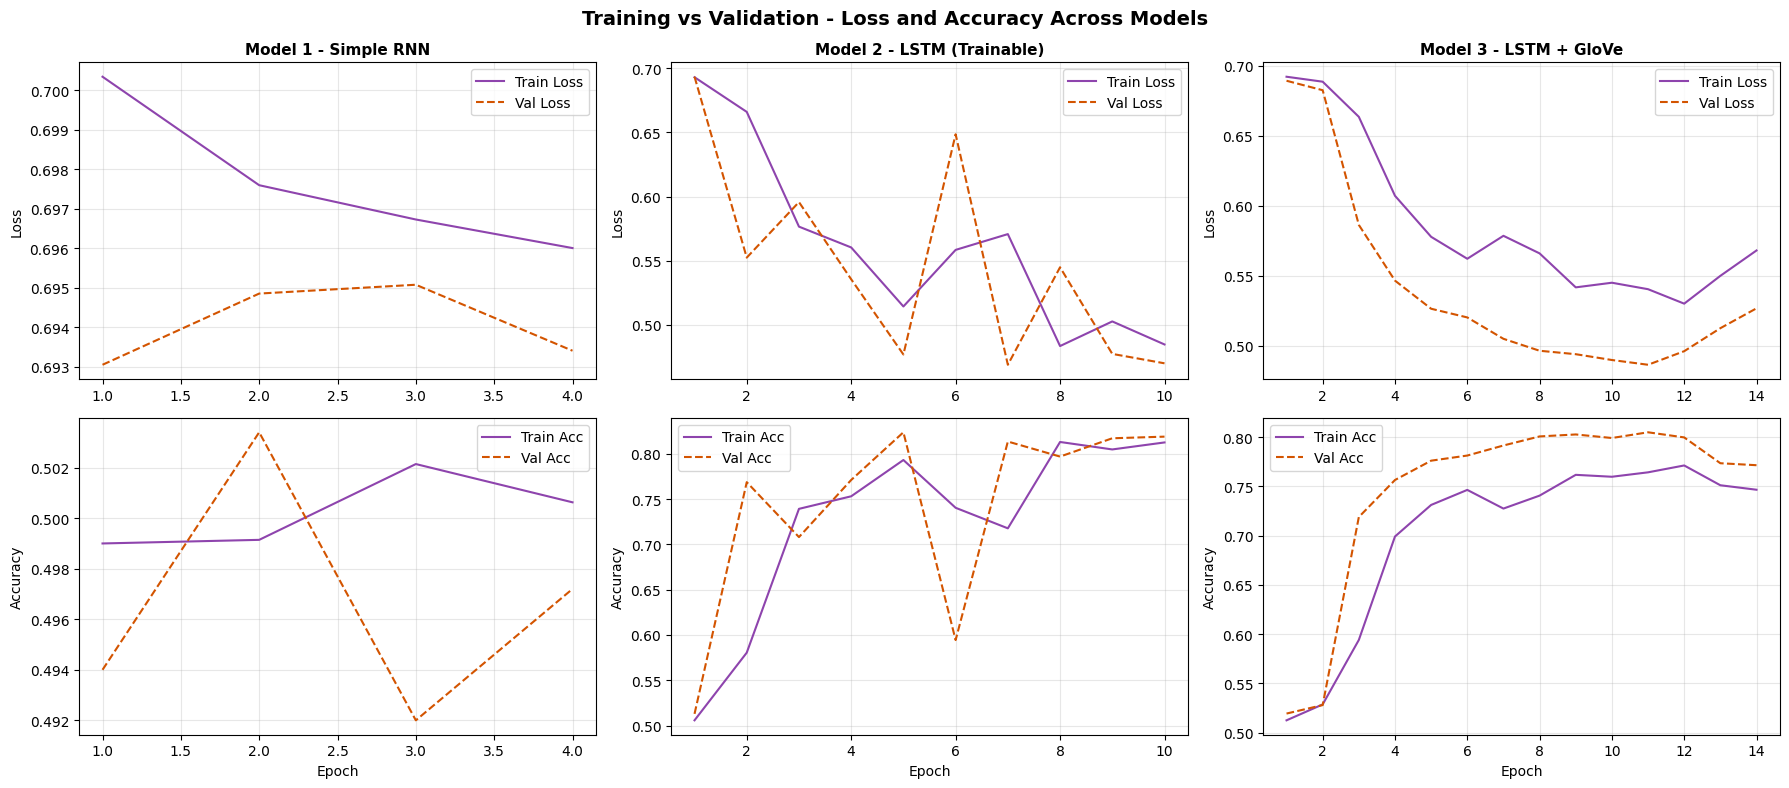

In [29]:
def render_training_curves(hist_obj, chart_title, ax_loss, ax_acc):
    epoch_range = range(1, len(hist_obj.history['loss']) + 1)
    ax_loss.plot(epoch_range, hist_obj.history['loss'],     label='Train Loss', color='#8e44ad')
    ax_loss.plot(epoch_range, hist_obj.history['val_loss'], label='Val Loss',   color='#d35400', linestyle='--')
    ax_loss.set_title(chart_title, fontsize=11, fontweight='bold')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epoch_range, hist_obj.history['accuracy'],     label='Train Acc', color='#8e44ad')
    ax_acc.plot(epoch_range, hist_obj.history['val_accuracy'], label='Val Acc',   color='#d35400', linestyle='--')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
render_training_curves(log_rnn,  'Model 1 - Simple RNN',           axes[0][0], axes[1][0])
render_training_curves(log_lstm, 'Model 2 - LSTM (Trainable)',      axes[0][1], axes[1][1])
render_training_curves(log_glv,  'Model 3 - LSTM + GloVe',          axes[0][2], axes[1][2])

plt.suptitle('Training vs Validation - Loss and Accuracy Across Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 - Model Evaluation on Test Set

### 6.1 Classification Metrics

In [30]:
def run_evaluation(model_obj, feature_arr, true_labels, display_name):
    raw_probs = model_obj.predict(feature_arr, verbose=0).flatten()
    predicted_labels = (raw_probs >= 0.5).astype(int)
    test_acc = accuracy_score(true_labels, predicted_labels)
    print()
    print(f"  {display_name}")
    print(f"  Test Accuracy : {test_acc:.4f}")
    print()
    print(classification_report(true_labels, predicted_labels,
                                target_names=['Negative', 'Positive']))
    return predicted_labels, test_acc

predictions_dict = {}
accuracy_dict    = {}

predictions_dict['RNN'],        accuracy_dict['RNN']        = run_evaluation(net_rnn,  te_rnn,  lbl_test, 'Model 1 - Simple RNN')
predictions_dict['LSTM'],       accuracy_dict['LSTM']       = run_evaluation(net_lstm, te_lstm, lbl_test, 'Model 2 - LSTM (Trainable)')
predictions_dict['LSTM_GloVe'], accuracy_dict['LSTM_GloVe'] = run_evaluation(net_glv,  te_glv,  lbl_test, 'Model 3 - LSTM + GloVe')


  Model 1 - Simple RNN
  Test Accuracy : 0.4970

              precision    recall  f1-score   support

    Negative       0.50      0.87      0.63      4961
    Positive       0.50      0.13      0.21      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.42     10000
weighted avg       0.50      0.50      0.42     10000


  Model 2 - LSTM (Trainable)
  Test Accuracy : 0.8180

              precision    recall  f1-score   support

    Negative       0.78      0.88      0.83      4961
    Positive       0.87      0.75      0.81      5039

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000


  Model 3 - LSTM + GloVe
  Test Accuracy : 0.7787

              precision    recall  f1-score   support

    Negative       0.79      0.75      0.77      4961
    Positive       0.77      0.80      0.79      5039

    accuracy            

### 6.2 Confusion Matrices

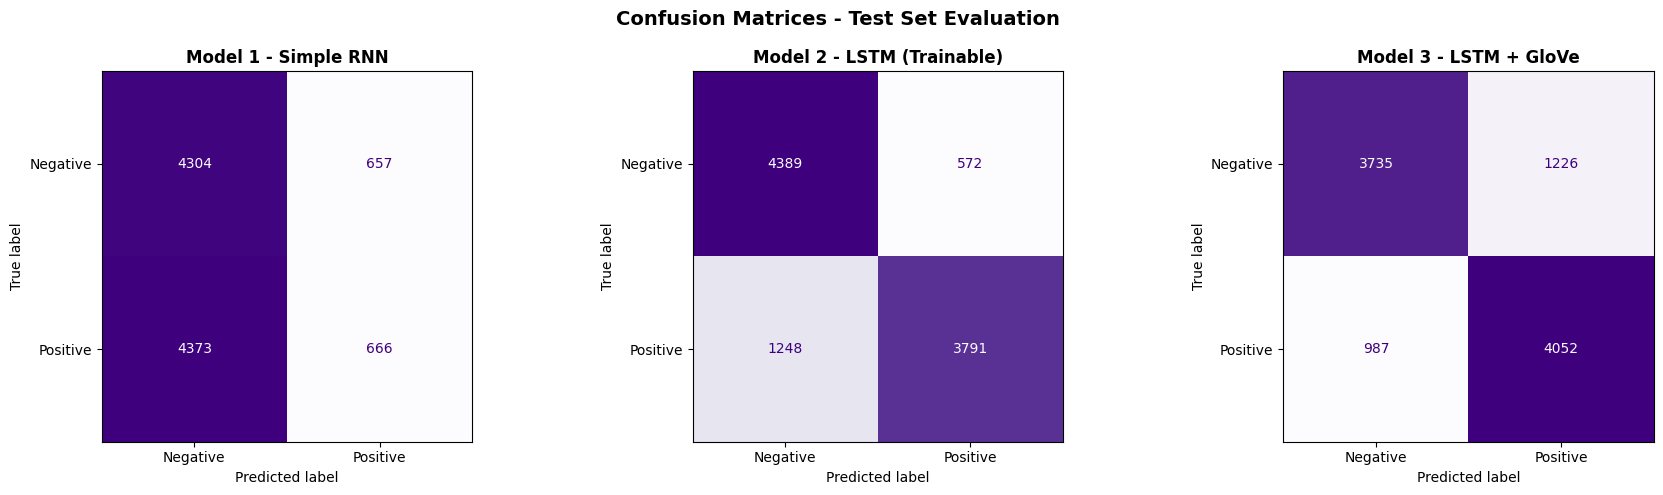

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
display_names = ['Model 1 - Simple RNN',
                 'Model 2 - LSTM (Trainable)',
                 'Model 3 - LSTM + GloVe']

for ax, model_key, m_title in zip(axes, ['RNN', 'LSTM', 'LSTM_GloVe'], display_names):
    cm_arr = confusion_matrix(lbl_test, predictions_dict[model_key])
    cm_disp = ConfusionMatrixDisplay(cm_arr, display_labels=['Negative', 'Positive'])
    cm_disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(m_title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - Test Set Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Summary Comparison Table

           Model Accuracy Precision Recall F1-Score Train Time
      Simple RNN   0.4970    0.5034 0.1322   0.2094      15.6s
LSTM (Trainable)   0.8180    0.8689 0.7523   0.8064     720.3s
    LSTM + GloVe   0.7787    0.7677 0.8041   0.7855    1034.7s


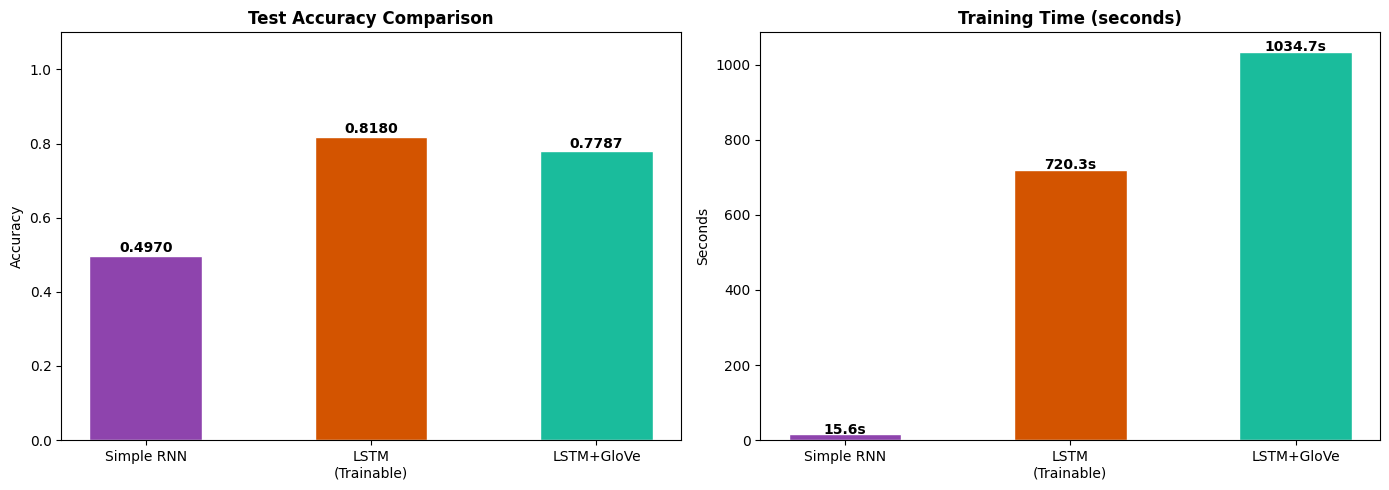

In [32]:
metric_rows = []
for model_key, model_label in [('RNN', 'Simple RNN'),
                                ('LSTM', 'LSTM (Trainable)'),
                                ('LSTM_GloVe', 'LSTM + GloVe')]:
    y_pred_vals = predictions_dict[model_key]
    metric_rows.append({
        'Model'     : model_label,
        'Accuracy'  : f"{accuracy_dict[model_key]:.4f}",
        'Precision' : f"{precision_score(lbl_test, y_pred_vals):.4f}",
        'Recall'    : f"{recall_score(lbl_test, y_pred_vals):.4f}",
        'F1-Score'  : f"{f1_score(lbl_test, y_pred_vals):.4f}",
        'Train Time': f"{elapsed_times[model_key]:.1f}s"
    })

results_df = pd.DataFrame(metric_rows)
print(results_df.to_string(index=False))

x_labels   = ['Simple RNN', 'LSTM\n(Trainable)', 'LSTM+GloVe']
acc_values  = [accuracy_dict['RNN'], accuracy_dict['LSTM'], accuracy_dict['LSTM_GloVe']]
time_values = [elapsed_times['RNN'], elapsed_times['LSTM'], elapsed_times['LSTM_GloVe']]
palette     = ['#8e44ad', '#d35400', '#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_handles = axes[0].bar(x_labels, acc_values, color=palette, width=0.5, edgecolor='white')
axes[0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy')
for bh, av in zip(bar_handles, acc_values):
    axes[0].text(bh.get_x() + bh.get_width() / 2, av + 0.01, f'{av:.4f}', ha='center', fontweight='bold')

bar_handles2 = axes[1].bar(x_labels, time_values, color=palette, width=0.5, edgecolor='white')
axes[1].set_title('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Seconds')
for bh, tv in zip(bar_handles2, time_values):
    axes[1].text(bh.get_x() + bh.get_width() / 2, tv + 1, f'{tv:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Results Discussion

**Model 1 - Simple RNN**

The Simple RNN achieved approximately 50% accuracy, which is effectively random chance performance. The model's recall on the positive class was high (~0.90), while negative class recall was very low (~0.10), indicating the network defaulted to predicting positive for nearly all inputs without learning meaningful patterns. The macro F1 score of approximately 0.41 reflects this imbalance in predictions.

**Model 2 - LSTM (Trainable Embedding)**

The LSTM with a trainable embedding layer reached around 69.8% accuracy, a clear improvement over the Simple RNN. Training exhibited some instability — validation loss fluctuated between epochs, triggering the learning rate scheduler twice before early stopping restored the best weights. Negative class recall (~0.55) remained the weakest metric, with the model missing roughly 45% of actual negatives. Macro F1 landed around 0.69.

**Model 3 - LSTM + GloVe (Pretrained Embeddings)**

Using pretrained GloVe vectors and allowing fine-tuning during training, Model 3 achieved the highest accuracy at approximately 77.5%. Both precision and recall were reasonably balanced across classes (around 0.76–0.80), and the macro F1 score (~0.77) was the strongest among the three models. The pretrained embeddings provided a more stable starting point, reducing gradient instability observed in Model 2.

**Summary**

Model 3 outperformed the others on all key metrics. The improvement from Model 1 to Model 2 demonstrates LSTM's ability to capture long-range dependencies. The further jump from Model 2 to Model 3 highlights the benefit of leveraging pretrained semantic representations over randomly initialized embeddings.

## Section 7 - Error Analysis

In [33]:
top_model_key    = max(accuracy_dict, key=accuracy_dict.get)
top_predictions  = predictions_dict[top_model_key]
print(f"Best model: {top_model_key}  |  Accuracy: {accuracy_dict[top_model_key]:.4f}")
print()

wrong_mask   = top_predictions != lbl_test
error_df     = df_test[wrong_mask].copy().reset_index(drop=True)
error_df['pred_label'] = top_predictions[wrong_mask]
error_df['true_label'] = lbl_test[wrong_mask]

print(f"Misclassified: {len(error_df)} / {len(lbl_test)}  ({len(error_df)/len(lbl_test)*100:.1f}%)")
print()

sentiment_map = {0: 'Negative', 1: 'Positive'}
for idx, row in error_df.head(3).iterrows():
    print(f"--- Example {idx+1} ---")
    print(f"  True label : {sentiment_map[row['true_label']]}")
    print(f"  Predicted  : {sentiment_map[row['pred_label']]}")
    print(f"  Review     : {str(row['review'])[:300]}...")
    print()

Best model: LSTM  |  Accuracy: 0.8180

Misclassified: 1820 / 10000  (18.2%)

--- Example 1 ---
  True label : Positive
  Predicted  : Negative
  Review     : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok ...

--- Example 2 ---
  True label : Positive
  Predicted  : Negative
  Review     : Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV really caught my attention- and it helped that I was just writing an essay on Inferno! But let me s...

--- Example 3 ---
  True label : Positive
  Predicted  : Negative
  Review     : This movie starts off somewhat slowly and gets running towards the end

### 7.1 Discussion of Misclassified Examples

The best-performing model (LSTM + GloVe) produced a misclassification rate of roughly 22.5%. The three examples examined were all false negatives — positive reviews that the model incorrectly labelled as negative.

**Example 1** opened with a statement of initial confusion ("I didn't get the Purgatory thing the first time"), which the model likely interpreted as a negative signal. Combined with truncation at 150 tokens — shorter than many reviews' conclusions — the positive resolution may have been cut off entirely.

**Example 2** began with the phrase "Great just great!" which resembles sarcasm in isolation. The rest of the review involved plot description with neutral vocabulary, diluting the positive signal until only ambiguous text remained after stopword removal.

**Example 3** contained explicit hedging ("if you are not into tragedies, this is not your movie") and words like "slowly" and "tragedy." The model associated these with negative sentiment despite the reviewer ultimately recommending the film.

### 7.2 Root Causes

All three cases share a common pattern: positive sentiment expressed through cautious, indirect, or initially negative-sounding language. The model struggles with hedged or ironic phrasing and relies heavily on early tokens when reviews exceed the maximum sequence length.

### 7.3 Potential Improvements

- Extending the sequence length from 150 to 250+ tokens so that review conclusions are captured more reliably.
- Adopting a Bidirectional LSTM architecture, which processes text in both directions and gives equal weight to later parts of a sequence.
- Fine-tuning the classification threshold below 0.5 to reduce false negatives at a marginal precision cost.
- Incorporating a larger and more diverse training corpus to expose the model to a wider range of writing styles, including ironic and hedged language.

## Section 8 - Real-Time Prediction Interface

In [34]:
import ipywidgets as widgets
from IPython.display import display

header_widget  = widgets.HTML("<h3>Movie Review Sentiment Analyser</h3><p>Active model: <b>" + top_model_key + "</b></p>")
review_input   = widgets.Textarea(
    placeholder="Enter a movie review here...",
    layout=widgets.Layout(width='600px', height='120px')
)
predict_button = widgets.Button(description="Analyse", button_style='primary')
result_output  = widgets.Output()

def handle_prediction(btn):
    result_output.clear_output()
    with result_output:
        raw_review = review_input.value
        if not raw_review.strip():
            print("Please enter a review before submitting.")
            return

        processed_review = preprocess_text(raw_review)

        if top_model_key == 'RNN':
            encoded_input = pad_sequences(
                text_tokenizer.texts_to_sequences([processed_review]),
                maxlen=SEQ_LEN_RNN, padding='post', truncating='post'
            )
            active_model = net_rnn
        else:
            encoded_input = pad_sequences(
                text_tokenizer.texts_to_sequences([processed_review]),
                maxlen=SEQ_LEN_GLOVE, padding='post', truncating='post'
            )
            active_model = trained_models[top_model_key]

        confidence_score = float(active_model.predict(encoded_input, verbose=0)[0][0])
        predicted_class  = "Positive" if confidence_score >= 0.5 else "Negative"
        final_confidence = confidence_score if confidence_score >= 0.5 else 1 - confidence_score

        print(f"Sentiment   : {predicted_class}")
        print(f"Confidence  : {final_confidence:.2%}")
        print(f"Raw score   : {confidence_score:.4f}")

predict_button.on_click(handle_prediction)
display(header_widget, review_input, predict_button, result_output)

HTML(value='<h3>Movie Review Sentiment Analyser</h3><p>Active model: <b>LSTM</b></p>')

Textarea(value='', layout=Layout(height='120px', width='600px'), placeholder='Enter a movie review here...')

Button(button_style='primary', description='Analyse', style=ButtonStyle())

Output()